In [7]:
# this block is just for finding indicator codes and fetching data from those we need.
from functools import reduce
import pandas as pd
import requests
import time
import json
import os

os.makedirs("raw_cache", exist_ok=True)

def find_who_indicator(search_term):
    """Query WHO's own indicator registry to find the correct code for a
    topic, instead of guessing a code from memory. Returns a DataFrame of
    matches so you can pick the exact one you want."""
    url = f"https://ghoapi.azureedge.net/api/Indicator?$filter=contains(IndicatorName,'{search_term}')"
    resp = requests.get(url, timeout=30)
    resp.raise_for_status()
    data = resp.json().get("value", [])
    return pd.DataFrame(data)[["IndicatorCode", "IndicatorName"]] if data else pd.DataFrame()
for term in ["Dengue", "Cholera", "air pollution", "Malaria", "Life expectancy"]:
    matches = find_who_indicator(term)
    print(f"\n--- matches for '{term}' ---")
    print(matches.to_string(index=False) if not matches.empty else "  NO MATCHES FOUND")
    time.sleep(0.3)


--- matches for 'Dengue' ---
  NO MATCHES FOUND

--- matches for 'Cholera' ---
     IndicatorCode                          IndicatorName
CHOLERA_0000000002 Number of reported deaths from cholera
CHOLERA_0000000001    Number of reported cases of cholera
CHOLERA_0000000003             Cholera case fatality rate
           WHS3_40     Cholera - number of reported cases

--- matches for 'air pollution' ---
IndicatorCode                                                                                          IndicatorName
       AIR_10                           Ambient air pollution  attributable DALYs per 100'000 children under 5 years
       AIR_12                                  Household air pollution attributable deaths in children under 5 years
       AIR_16                                   Household air pollution attributable DALYs in children under 5 years
       AIR_11                                                            Household air pollution attributable deaths
       A

In [8]:
#entering the required indicators and checking their record abundance
who_indicators = {
    "MALARIA_EST_CASES": "malaria_cases",
    "WHOSIS_000001": "life_expectancy",
    "CHOLERA_0000000001": "cholera_cases",
    "AIR_41": "air_pollution_deaths",
}

def fetch_who_indicator(code, col_name):
    url = f"https://ghoapi.azureedge.net/api/{code}"
    try:
        resp = requests.get(url, timeout=30)
        resp.raise_for_status()
    except requests.RequestException as e:
        print(f"  [FAILED] {code}: {e}")
        return None
    payload = resp.json()
    with open(f"raw_cache/who_{code}.json", "w") as f:
        json.dump(payload, f)
    records = payload.get("value", [])
    if not records:
        print(f"  [WARNING] {code} returned 0 records — code is likely wrong or deprecated")
        return None

    df = pd.DataFrame(records)
    df = df[df["SpatialDimType"] == "COUNTRY"]
    if df.empty:
        print(f"  [WARNING] {code} had records but none at COUNTRY level")
        return None
    df = df[["SpatialDim", "TimeDim", "NumericValue"]].copy()
    df.columns = ["country_code", "year", col_name]
    df["year"] = df["year"].astype(int)
    df = df.groupby(["country_code", "year"])[col_name].mean().reset_index()
    print(f"  [OK] {code} -> '{col_name}': {len(df)} country-year records, "
          f"{df['country_code'].nunique()} countries, years {df['year'].min()}-{df['year'].max()}")
    return df

print("Fetching WHO data...")
who_dfs = []
for code, col_name in who_indicators.items():
    df = fetch_who_indicator(code, col_name)
    if df is not None:
        who_dfs.append(df)
    time.sleep(0.3)
if not who_dfs:
    raise RuntimeError("No WHO indicators fetched successfully — check codes above")

who_master = reduce(
    lambda left, right: pd.merge(left, right, on=["country_code", "year"], how="outer"),
    who_dfs,
)
print(f"\nWHO master: {who_master.shape[0]} rows, {who_master.shape[1]} columns")

Fetching WHO data...
  [OK] MALARIA_EST_CASES -> 'malaria_cases': 2723 country-year records, 110 countries, years 2000-2024
  [OK] WHOSIS_000001 -> 'life_expectancy': 4070 country-year records, 185 countries, years 2000-2021
  [OK] CHOLERA_0000000001 -> 'cholera_cases': 2469 country-year records, 161 countries, years 1949-2016
  [OK] AIR_41 -> 'air_pollution_deaths': 185 country-year records, 185 countries, years 2021-2021

WHO master: 6025 rows, 6 columns


In [9]:
#co2 dataset

wb_file = "API_EN.GHG.CO2.MT.CE.AR5_DS2_en_csv_v2_34526.csv"

wb = pd.read_csv(wb_file, skiprows=4)

#renaming country code to match WHO's and some formatting
wb = wb.rename(columns={
    "Country Code": "country_code"
})

wb = wb.melt(
    id_vars=["Country Name", "country_code", "Indicator Name", "Indicator Code"],
    var_name="year",
    value_name="co2_emissions"
)
wb["year"] = pd.to_numeric(wb["year"], errors="coerce")
wb = wb.dropna(subset=["country_code", "year", "co2_emissions"])
wb["year"] = wb["year"].astype(int)
wb_master = wb[["country_code", "year", "co2_emissions"]]

print(
    f"World Bank: {wb_master.shape[0]} rows, "
    f"{wb_master.shape[1]} columns"
)
print(wb_master.head())

World Bank: 13750 rows, 3 columns
     country_code  year  co2_emissions
2650          ABW  1970         0.0254
2651          AFE  1970       228.5328
2652          AFG  1970         1.7328
2653          AFW  1970        43.1109
2654          AGO  1970         8.9339


In [10]:
#merging
merged_outer = pd.merge(
    who_master,
    wb_master,
    on=["country_code", "year"],
    how="outer"
)
merged_inner = pd.merge(
    who_master,
    wb_master,
    on=["country_code", "year"],
    how="inner"
)

print(f"Outer join: {merged_outer.shape[0]} rows")
print(f"Inner join: {merged_inner.shape[0]} rows  "
      f"({merged_inner.shape[0]/merged_outer.shape[0]:.1%} of outer)")
print("\nMissingness in outer-joined data:")
print(
    merged_outer.isna()
    .mean()
    .sort_values(ascending=False)
    .round(3)
)

merged_df = (
    merged_inner
    .sort_values(["country_code", "year"])
    .reset_index(drop=True)
)
merged_df.to_csv("raw_cache/merged_master.csv", index=False)
merged_df.head(10)

Outer join: 14050 rows
Inner join: 5725 rows  (40.7% of outer)

Missingness in outer-joined data:
air_pollution_deaths    0.987
cholera_cases           0.985
malaria_cases           0.806
life_expectancy         0.710
co2_emissions           0.021
year                    0.000
country_code            0.000
dtype: float64


,country_code,year,malaria_cases,life_expectancy,cholera_cases,air_pollution_deaths,co2_emissions
0,AFG,1993,NaN,NaN,NaN,NaN,1.7729
1,AFG,1994,NaN,NaN,NaN,NaN,1.6737
2,AFG,1995,NaN,NaN,NaN,NaN,1.4526
3,AFG,1997,NaN,NaN,NaN,NaN,1.3735
4,AFG,1998,NaN,NaN,NaN,NaN,1.4093
5,AFG,1999,NaN,NaN,NaN,NaN,1.3633
6,AFG,2000,1312939.0,53.834299,NaN,NaN,1.0093
7,AFG,2001,1312939.0,53.921629,NaN,NaN,0.9402
8,AFG,2002,1382972.0,55.159352,NaN,NaN,0.9388
9,AFG,2003,1242906.0,56.092501,NaN,NaN,1.0172


In [11]:
#checking total number of observations

print("Total rows in inner merge:", len(merged_inner))

print("\nRows with each variable available:")
for col in [
    "malaria_cases",
    "life_expectancy",
    "cholera_cases",
    "air_pollution_deaths",
    "co2_emissions"
]:
    print(f"{col}: {merged_inner[col].notna().sum()}")

print("\nRows with WHO + CO2 variables:")
print(
    merged_inner[
        [
            "malaria_cases",
            "life_expectancy",
            "cholera_cases",
            "air_pollution_deaths",
            "co2_emissions"
        ]
    ].notna().all(axis=1).sum()
)

Total rows in inner merge: 5725

Rows with each variable available:
malaria_cases: 2651
life_expectancy: 3982
cholera_cases: 213
air_pollution_deaths: 181
co2_emissions: 5725

Rows with WHO + CO2 variables:
0


In [12]:
# malaria + co2
malaria_df = merged_inner.dropna(
    subset=["malaria_cases", "co2_emissions"]
).copy()

# life expectancy + co2
life_df = merged_inner.dropna(
    subset=["life_expectancy", "co2_emissions"]
).copy()

# cholera + co2
cholera_df = merged_inner.dropna(
    subset=["cholera_cases", "co2_emissions"]
).copy()

# air pollution deaths + co2
air_df = merged_inner.dropna(
    subset=["air_pollution_deaths", "co2_emissions"]
).copy()

print("Malaria + CO2:", len(malaria_df))
print("Life expectancy + CO2:", len(life_df))
print("Cholera + CO2:", len(cholera_df))
print("Air pollution + CO2:", len(air_df))

Malaria + CO2: 2651
Life expectancy + CO2: 3982
Cholera + CO2: 213
Air pollution + CO2: 181


In [13]:
for name, df in [("malaria", malaria_df), ("life", life_df), ("cholera", cholera_df), ("air", air_df)]:
    print(f"{name}: {len(df)} rows | {df['country_code'].nunique()} countries | years {df['year'].min()}-{df['year'].max()}")
# this shows that there isnt enough data for cholera and barely any for air. this is the reason we take another dataset instead for air pollution that measures
# the exposure to pm 2.5 air instead of measuring mortality rate. we can compare this with co2 per capita and come to an environmental insight instead of the health
# insight we will arrive at with the other two datasets (malaria and life expectancy). we will not treat cholera as a time analysis / trend over the years parameter
# since a 5 year window (2011-16) only makes the graphs noisier. we can plot it/analyse it for a single point in time instead.

malaria: 2651 rows | 107 countries | years 2000-2024
life: 3982 rows | 181 countries | years 2000-2021
cholera: 213 rows | 70 countries | years 2011-2016
air: 181 rows | 181 countries | years 2021-2021


In [14]:
for col in ["malaria_cases", "cholera_cases", "air_pollution_deaths", "life_expectancy"]:
    sub = who_master.dropna(subset=[col])
    print(f"{col}: years {sub['year'].min()}-{sub['year'].max()} | "
          f"n={len(sub)} | countries={sub['country_code'].nunique()}")

malaria_cases: years 2000-2024 | n=2723 | countries=110
cholera_cases: years 2011-2016 | n=216 | countries=71
air_pollution_deaths: years 2021-2021 | n=185 | countries=185
life_expectancy: years 2000-2021 | n=4070 | countries=185


In [15]:
print(who_indicators)
who_dfs = []
for code, col_name in who_indicators.items():
    df = fetch_who_indicator(code, col_name)
    if df is not None:
        who_dfs.append(df)
who_master = reduce(
    lambda left, right: pd.merge(left, right, on=["country_code", "year"], how="outer"),
    who_dfs,
)
print(f"WHO master: {who_master.shape[0]} rows, {who_master.shape[1]} columns")

for col in ["malaria_cases", "cholera_cases", "air_pollution_deaths", "life_expectancy"]:
    sub = who_master.dropna(subset=[col])
    print(f"{col}: years {sub['year'].min()}-{sub['year'].max()} | "
          f"n={len(sub)} | countries={sub['country_code'].nunique()}")

{'MALARIA_EST_CASES': 'malaria_cases', 'WHOSIS_000001': 'life_expectancy', 'CHOLERA_0000000001': 'cholera_cases', 'AIR_41': 'air_pollution_deaths'}
  [OK] MALARIA_EST_CASES -> 'malaria_cases': 2723 country-year records, 110 countries, years 2000-2024
  [OK] WHOSIS_000001 -> 'life_expectancy': 4070 country-year records, 185 countries, years 2000-2021
  [OK] CHOLERA_0000000001 -> 'cholera_cases': 2469 country-year records, 161 countries, years 1949-2016
  [OK] AIR_41 -> 'air_pollution_deaths': 185 country-year records, 185 countries, years 2021-2021
WHO master: 6025 rows, 6 columns
malaria_cases: years 2000-2024 | n=2723 | countries=110
cholera_cases: years 2011-2016 | n=216 | countries=71
air_pollution_deaths: years 2021-2021 | n=185 | countries=185
life_expectancy: years 2000-2021 | n=4070 | countries=185


In [16]:
# population file
pop_file = "API_SP.POP.TOTL_DS2_en_csv_v2_33112.csv"
pop = pd.read_csv(pop_file, skiprows=4)
pop = pop.rename(columns={"Country Code": "country_code"})
pop = pop.melt(
    id_vars=["Country Name", "country_code", "Indicator Name", "Indicator Code"],
    var_name="year", value_name="population"
)
pop["year"] = pd.to_numeric(pop["year"], errors="coerce")
pop = pop.dropna(subset=["country_code", "year", "population"])
pop["year"] = pop["year"].astype(int)
pop_master = pop[["country_code", "year", "population"]]
print(f"pop_master shape: {pop_master.shape}")
pop_master.head()

pop_master shape: (17394, 3)


,country_code,year,population
0,ABW,1960,54922.0
1,AFE,1960,130075728.0
2,AFG,1960,9035043.0
3,AFW,1960,97630925.0
4,AGO,1960,5231654.0


In [17]:
merged_inner = merged_inner.drop(columns=["population"], errors="ignore")
merged_inner = merged_inner.merge(pop_master, on=["country_code", "year"], how="inner")
print(merged_inner.shape)
print(merged_inner.columns.tolist())
merged_inner["population"].describe()

(5725, 8)
['country_code', 'year', 'malaria_cases', 'life_expectancy', 'cholera_cases', 'air_pollution_deaths', 'co2_emissions', 'population']


count    5.725000e+03
mean     4.489000e+07
std      1.499455e+08
min      7.298000e+03
25%      3.274400e+06
50%      1.016616e+07
75%      3.128457e+07
max      1.450936e+09
Name: population, dtype: float64

In [18]:
print(merged_inner.columns.tolist())

['country_code', 'year', 'malaria_cases', 'life_expectancy', 'cholera_cases', 'air_pollution_deaths', 'co2_emissions', 'population']


In [19]:
merged_inner["malaria_per_100k"] = merged_inner["malaria_cases"] / merged_inner["population"] * 1e5
merged_inner["cholera_per_100k"] = merged_inner["cholera_cases"] / merged_inner["population"] * 1e5
merged_inner["air_pollution_deaths_per_100k"] = merged_inner["air_pollution_deaths"] / merged_inner["population"] * 1e5
merged_inner["co2_per_capita"] = merged_inner["co2_emissions"] * 1e6 / merged_inner["population"]
merged_inner[["country_code", "year", "malaria_per_100k", "cholera_per_100k",
              "air_pollution_deaths_per_100k", "co2_per_capita"]].describe()

,year,malaria_per_100k,cholera_per_100k,air_pollution_deaths_per_100k,co2_per_capita
count,5725.000000,2651.000000,213.000000,181.000000,5725.000000
mean,2005.227249,9776.194606,23.984477,9.186022,4.222832
std,13.120187,14866.196641,99.281776,6.033033,6.097791
min,1970.000000,0.000000,0.000693,1.710987,0.000000
25%,2000.000000,4.809023,0.021994,5.480535,0.408920
50%,2007.000000,443.312990,0.568456,7.683338,1.732549
75%,2015.000000,17340.643257,5.388996,10.388257,5.942902
max,2024.000000,71178.923371,1112.994526,39.745277,72.068548


In [20]:
merged_inner.sort_values("malaria_per_100k", ascending=False)[
    ["country_code", "year", "malaria_cases", "population", "malaria_per_100k"]
].head(15)

,country_code,year,malaria_cases,population,malaria_per_100k
4586,SLB,2004,337823.0,474611.0,71178.923371
4423,RWA,2017,8681013.0,12202060.0,71143.831451
4583,SLB,2001,285929.0,449125.0,63663.568049
4584,SLB,2002,280109.0,457671.0,61203.135003
431,BFA,2001,7346774.0,12295001.0,59754.155368
430,BFA,2000,7121621.0,11925546.0,59717.358014
432,BFA,2002,7513033.0,12680897.0,59246.857695
4587,SLB,2005,286015.0,483080.0,59206.549640
433,BFA,2003,7615906.0,13082532.0,58214.312031
4582,SLB,2000,254582.0,440469.0,57797.938107


In [21]:
merged_inner["life_expectancy"].describe()

count    3982.000000
mean       70.185226
std         8.647625
min        40.160811
25%        64.479757
50%        72.253402
75%        76.704157
max        84.638818
Name: life_expectancy, dtype: float64

metadata

In [22]:
meta_file = "Metadata_Country_API_EN.GHG.CO2.MT.CE.AR5_DS2_en_csv_v2_34526.csv"
meta = pd.read_csv(meta_file)
meta = meta.rename(columns={"Country Code": "country_code"})
meta = meta[["country_code", "Region", "IncomeGroup", "TableName"]]

before = meta["country_code"].nunique()
meta = meta.dropna(subset=["IncomeGroup"])
print(f"Dropped {before - meta['country_code'].nunique()} non-country aggregate rows")
print(meta["IncomeGroup"].value_counts())

Dropped 47 non-country aggregate rows
IncomeGroup
High income            86
Upper middle income    59
Lower middle income    47
Low income             25
Name: count, dtype: int64


GDP

In [23]:
gdp_file = "API_NY.GDP.PCAP.CD_DS2_en_csv_v2_33610.csv"
gdp = pd.read_csv(gdp_file, skiprows=4)
gdp = gdp.rename(columns={"Country Code": "country_code"})
gdp = gdp.melt(
    id_vars=["Country Name", "country_code", "Indicator Name", "Indicator Code"],
    var_name="year", value_name="gdp_per_capita"
)
gdp["year"] = pd.to_numeric(gdp["year"], errors="coerce")
gdp = gdp.dropna(subset=["country_code", "year", "gdp_per_capita"])
gdp["year"] = gdp["year"].astype(int)
gdp_master = gdp[["country_code", "year", "gdp_per_capita"]]

print(f"gdp_master: {gdp_master.shape}")

gdp_master: (14745, 3)


In [24]:
merged_inner = merged_inner.merge(gdp_master, on=["country_code", "year"], how="inner")
merged_inner = merged_inner.merge(meta, on="country_code", how="left")

print(merged_inner.shape)
print(merged_inner.columns.tolist())

(5602, 16)
['country_code', 'year', 'malaria_cases', 'life_expectancy', 'cholera_cases', 'air_pollution_deaths', 'co2_emissions', 'population', 'malaria_per_100k', 'cholera_per_100k', 'air_pollution_deaths_per_100k', 'co2_per_capita', 'gdp_per_capita', 'Region', 'IncomeGroup', 'TableName']


In [25]:
outcomes = {
    "malaria": "malaria_per_100k",
    "cholera": "cholera_per_100k",
    "air_pollution": "air_pollution_deaths_per_100k",
    "life_expectancy": "life_expectancy",
}

subsets = {}
for name, col in outcomes.items():
    df = merged_inner.dropna(subset=[col, "co2_per_capita", "gdp_per_capita", "IncomeGroup"]).copy()
    subsets[name] = df
    print(f"{name}: {len(df)} rows | {df['country_code'].nunique()} countries | "
          f"years {df['year'].min()}-{df['year'].max()}")

malaria: 2605 rows | 106 countries | years 2000-2024
cholera: 213 rows | 70 countries | years 2011-2016
air_pollution: 177 rows | 177 countries | years 2021-2021
life_expectancy: 3946 rows | 180 countries | years 2000-2021


fixing air pollution thing

In [ ]:
%pip install pycountry
import pycountry
valid_iso3 = {c.alpha_3 for c in pycountry.countries}

pm25_file = "WB_WDI_EN_ATM_PM25_MC_M3.csv"
pm25 = pd.read_csv(pm25_file)
pm25 = pm25.rename(columns={"REF_AREA": "country_code", "TIME_PERIOD": "year", "OBS_VALUE": "pm25_exposure"})
pm25 = pm25[["country_code", "year", "pm25_exposure"]].dropna()
pm25["year"] = pm25["year"].astype(int)

before = pm25["country_code"].nunique()
pm25_clean = pm25[pm25["country_code"].isin(valid_iso3)].copy()
print(f"Dropped {before - pm25_clean['country_code'].nunique()} non-country codes")

air_df = pm25_clean.merge(wb_master, on=["country_code", "year"], how="inner")
air_df = air_df.merge(pop_master, on=["country_code", "year"], how="inner")
air_df = air_df.merge(gdp_master, on=["country_code", "year"], how="inner")
air_df = air_df.merge(meta, on="country_code", how="left")
air_df["co2_per_capita"] = air_df["co2_emissions"] * 1e6 / air_df["population"]
air_df = air_df.dropna(subset=["pm25_exposure", "co2_per_capita", "gdp_per_capita", "IncomeGroup"])

subsets["air_pollution"] = air_df

print(f"\nair_df: {len(air_df)} rows | {air_df['country_code'].nunique()} countries | "
      f"years {air_df['year'].min()}-{air_df['year'].max()}")

Dropped 47 non-country codes

air_df: 6429 rows | 192 countries | years 1990-2023


In [27]:
for name, df in subsets.items():
    counts = df["country_code"].value_counts()
    print(f"{name}: {len(df)} rows | {df['country_code'].nunique()} countries | "
          f"years {df['year'].min()}-{df['year'].max()} | "
          f"countries with 2+ years: {(counts >= 2).sum()}")

malaria: 2605 rows | 106 countries | years 2000-2024 | countries with 2+ years: 105
cholera: 213 rows | 70 countries | years 2011-2016 | countries with 2+ years: 51
air_pollution: 6429 rows | 192 countries | years 1990-2023 | countries with 2+ years: 192
life_expectancy: 3946 rows | 180 countries | years 2000-2021 | countries with 2+ years: 180


In [28]:
merged_inner[["population", "co2_per_capita", "malaria_per_100k"]].describe()

,population,co2_per_capita,malaria_per_100k
count,5.602000e+03,5602.000000,2605.000000
mean,4.541020e+07,4.279831,9921.537392
std,1.515013e+08,6.138307,14953.459762
min,7.298000e+03,0.000000,0.000000
25%,3.230847e+06,0.438446,4.359206
50%,1.011762e+07,1.763551,452.806857
75%,3.152717e+07,6.091330,18302.049962
max,1.450936e+09,72.068548,71178.923371


In [29]:
air_df[["population", "co2_per_capita", "pm25_exposure"]].describe()

,population,co2_per_capita,pm25_exposure
count,6.429000e+03,6429.000000,6429.000000
mean,3.498548e+07,4.925405,24.294712
std,1.321267e+08,9.829569,15.637865
min,8.798000e+03,0.000000,1.386852
25%,1.503091e+06,0.500068,13.423069
50%,6.824132e+06,2.017723,20.910963
75%,2.266211e+07,6.331073,31.744570
max,1.438070e+09,202.865184,124.657449


In [33]:
analysis_data = {
    "Malaria": merged_inner[
        ["country_code", "year", "IncomeGroup",
         "co2_per_capita", "malaria_per_100k"]
    ].dropna(),

    "Cholera": merged_inner[
        ["country_code", "year", "IncomeGroup",
         "co2_per_capita", "cholera_per_100k"]
    ].dropna(),

    "Life Expectancy": merged_inner[
        ["country_code", "year", "IncomeGroup",
         "co2_per_capita", "life_expectancy"]
    ].dropna(),

    "Air Pollution (PM2.5)": air_df[
        ["country_code", "year", "IncomeGroup",
         "co2_per_capita", "pm25_exposure"]
    ].dropna()
}

for name, df in analysis_data.items():
    print(f"{name}: {len(df)} observations, "
          f"{df['country_code'].nunique()} countries")

Malaria: 2605 observations, 106 countries
Cholera: 213 observations, 70 countries
Life Expectancy: 3946 observations, 180 countries
Air Pollution (PM2.5): 6429 observations, 192 countries


In [32]:
from scipy.stats import pearsonr
import pandas as pd

In [34]:
results = []

for outcome, df in analysis_data.items():

    value_col = {
        "Malaria": "malaria_per_100k",
        "Cholera": "cholera_per_100k",
        "Life Expectancy": "life_expectancy",
        "Air Pollution (PM2.5)": "pm25_exposure"
    }[outcome]

    for income_group, group in df.groupby("IncomeGroup"):

        # Need at least 3 observations
        if len(group) >= 3:
            r, p = pearsonr(
                group["co2_per_capita"],
                group[value_col]
            )

            results.append({
                "IncomeGroup": income_group,
                "Outcome": outcome,
                "Correlation": r,
                "P_value": p,
                "Observations": len(group)
            })

income_corr = pd.DataFrame(results)

income_corr

,IncomeGroup,Outcome,Correlation,P_value,Observations
0,High income,Malaria,-0.383690,1.593807e-07,175
1,Low income,Malaria,-0.380242,1.686943e-20,554
2,Lower middle income,Malaria,-0.325547,2.406263e-27,1050
3,Upper middle income,Malaria,0.034228,3.258454e-01,826
4,High income,Cholera,0.276659,5.430870e-02,49
5,Low income,Cholera,-0.010127,9.426277e-01,53
6,Lower middle income,Cholera,-0.118468,3.181609e-01,73
7,Upper middle income,Cholera,-0.271696,9.892170e-02,38
8,High income,Life Expectancy,-0.051172,6.764831e-02,1276
9,Low income,Life Expectancy,0.524668,3.208717e-36,493


In [35]:
income_corr_table = income_corr.pivot(
    index="IncomeGroup",
    columns="Outcome",
    values="Correlation"
)

income_corr_table.round(3)

Outcome,Air Pollution (PM2.5),Cholera,Life Expectancy,Malaria
IncomeGroup,,,,
High income,0.309,0.277,-0.051,-0.384
Low income,0.004,-0.010,0.525,-0.380
Lower middle income,-0.020,-0.118,0.448,-0.326
Upper middle income,0.280,-0.272,-0.142,0.034


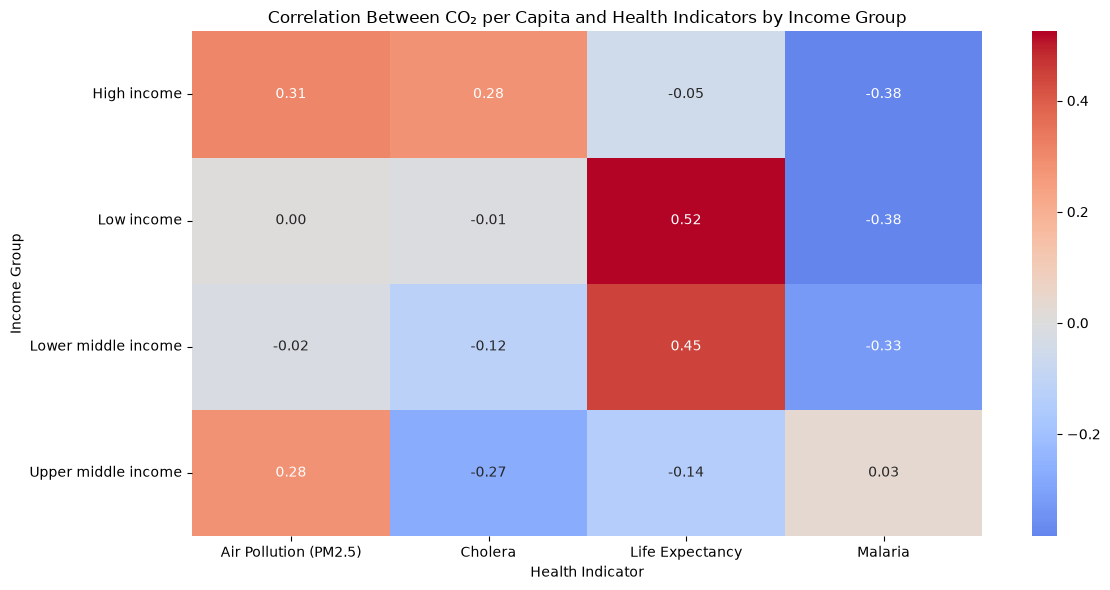

In [36]:
# Visualize income-wise correlations
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

sns.heatmap(
    income_corr_table,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)

plt.title("Correlation Between CO₂ per Capita and Health Indicators by Income Group")
plt.xlabel("Health Indicator")
plt.ylabel("Income Group")
plt.tight_layout()
plt.show()

In [37]:
# Visualize WITHIN-COUNTRY CORRELATION

country_results = []

for outcome, df in analysis_data.items():

    value_col = {
        "Malaria": "malaria_per_100k",
        "Cholera": "cholera_per_100k",
        "Life Expectancy": "life_expectancy",
        "Air Pollution (PM2.5)": "pm25_exposure"
    }[outcome]

    for country, group in df.groupby("country_code"):

        # At least 5 yearly observations
        if len(group) >= 5:

            r, p = pearsonr(
                group["co2_per_capita"],
                group[value_col]
            )

            country_results.append({
                "Country": country,
                "Outcome": outcome,
                "Correlation": r,
                "P_value": p,
                "Years": len(group)
            })

country_corr = pd.DataFrame(country_results)

country_corr.head(20)


C:\Users\MUIN\AppData\Local\Temp\ipykernel_16788\221772832.py:19: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = pearsonr(


,Country,Outcome,Correlation,P_value,Years
0,AFG,Malaria,-0.729834,3.465461e-05,25
1,AGO,Malaria,-0.412020,4.070168e-02,25
2,ARE,Malaria,NaN,NaN,25
3,ARG,Malaria,-0.474433,1.656658e-02,25
4,ARM,Malaria,-0.596094,1.663368e-03,25
5,AZE,Malaria,-0.075490,7.198645e-01,25
6,BDI,Malaria,0.292939,1.552854e-01,25
7,BEN,Malaria,-0.428712,3.249225e-02,25
8,BFA,Malaria,-0.937000,5.453495e-12,25
9,BGD,Malaria,-0.923260,4.923275e-11,25


In [38]:
country_corr_table = country_corr.pivot(
    index="Country",
    columns="Outcome",
    values="Correlation"
)

country_corr_table.round(3)

Outcome,Air Pollution (PM2.5),Cholera,Life Expectancy,Malaria
Country,,,,
AFG,-0.713,-0.333,0.873,-0.730
AGO,0.335,NaN,-0.048,-0.412
ALB,-0.648,NaN,0.790,NaN
ARE,-0.074,NaN,-0.432,NaN
ARG,-0.906,NaN,0.710,-0.474
...,...,...,...,...
WSM,-0.414,NaN,0.050,NaN
YEM,-0.385,NaN,-0.120,0.350
ZAF,0.318,NaN,-0.407,0.080


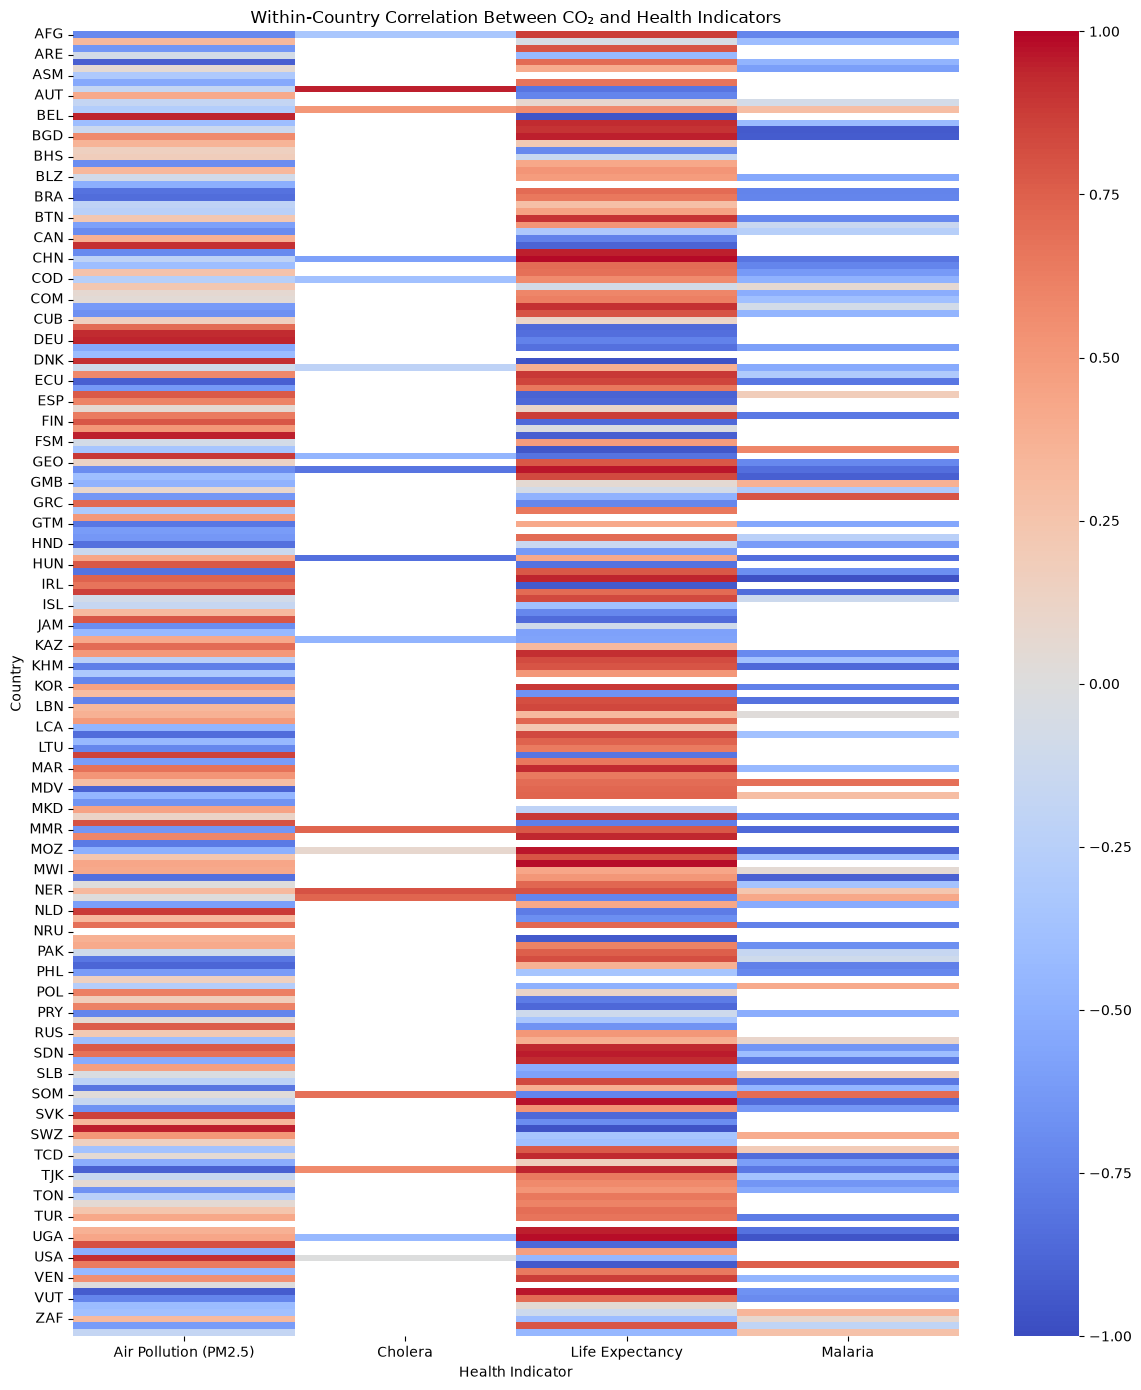

In [39]:
plt.figure(figsize=(12, 14))

sns.heatmap(
    country_corr_table,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1
)

plt.title("Within-Country Correlation Between CO₂ and Health Indicators")
plt.xlabel("Health Indicator")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

In [40]:
country_corr.sort_values(
    "Correlation",
    ascending=False
).head(20)

,Country,Outcome,Correlation,P_value,Years
154,CHN,Life Expectancy,0.985922,5.206543e-17,22
289,UGA,Life Expectancy,0.981959,6.120945e-16,22
237,MUS,Life Expectancy,0.977810,4.767445e-15,22
270,STP,Life Expectancy,0.975276,1.391122e-14,22
296,VNM,Life Expectancy,0.966909,2.478441e-13,22
184,GHA,Life Expectancy,0.965433,3.811324e-13,22
235,MOZ,Life Expectancy,0.961096,1.220458e-12,22
263,SDN,Life Expectancy,0.954434,5.767039e-12,22
137,BGD,Life Expectancy,0.952285,9.061484e-12,22
106,AUS,Cholera,0.951928,1.256059e-02,5


In [41]:
country_corr.sort_values(
    "Correlation",
    ascending=True
).head(20)

,Country,Outcome,Correlation,P_value,Years
44,IND,Malaria,-0.972522,4.661370e-16,25
274,SWE,Life Expectancy,-0.965896,3.336245e-13,22
168,DNK,Life Expectancy,-0.963832,5.953684e-13,22
134,BEL,Life Expectancy,-0.957983,2.601480e-12,22
96,UGA,Malaria,-0.955175,1.190414e-13,25
181,GAB,Life Expectancy,-0.951111,1.149907e-11,22
8,BFA,Malaria,-0.937000,5.453495e-12,25
293,UZB,Life Expectancy,-0.935974,1.601485e-10,22
199,IRL,Life Expectancy,-0.935900,1.619730e-10,22
247,NZL,Life Expectancy,-0.933249,2.401939e-10,22


In [42]:
income_corr.to_csv(
    "income_group_correlations.csv",
    index=False
)

country_corr.to_csv(
    "within_country_correlations.csv",
    index=False
)

income_corr_table.to_csv(
    "income_group_correlation_table.csv"
)

country_corr_table.to_csv(
    "country_correlation_table.csv"
)

print("Correlation results saved successfully.")

Correlation results saved successfully.
